In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline


In [13]:
df = pd.read_csv('./data_public.csv')
df.head()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,Class
0,231.420023,-12.210984,217.624839,-15.611916,140.047185,76.904999,131.591871,198.160805,82.873279,127.350084,224.592926,-5.992983,-14.689648,143.072058,153.439659,2
1,-38.019270,-14.195695,9.583547,22.293822,-25.578283,-18.373955,-0.094457,-33.711852,-8.356041,23.792402,4.199023,2.809159,-59.330681,-11.685950,1.317104,3
2,-39.197085,-20.418850,21.023083,19.790280,-25.902587,-19.189004,-2.953836,-25.299219,-6.612401,26.285392,5.911292,6.191587,-56.924996,-4.675187,-1.027830,2
3,221.630408,-5.785352,216.725322,-9.900781,126.795177,85.122288,108.857593,197.640135,82.560019,157.105143,212.989231,-3.621070,-15.469156,135.265859,149.212489,2
4,228.558412,-12.447710,204.637218,-13.277704,138.930529,91.101870,115.598954,209.300011,89.961688,130.299732,201.795100,-1.573922,-15.128603,148.368622,147.492663,3


In [14]:
labels = df.columns.tolist()[:-1]
X = pd.DataFrame(data=df.drop('Class', axis=1),
columns=labels)
y = pd.DataFrame(data=df['Class'],
columns=['Class'])
X_train, X_test, y_train, y_test = train_test_split(X,
y,
test_size=0.3)
training_data = pd.concat([X_train,
y_train],
axis=1)
training_data.head()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,Class
667226,-59.965333,-53.027996,-42.428654,-113.718763,-17.852352,-125.145629,-53.541906,-12.676369,53.500809,-94.278932,50.179721,-49.862247,-53.985673,31.394646,66.431011,2
151541,-29.045034,-9.588767,15.212665,18.206499,-22.882630,-29.321293,2.003450,-24.901611,-7.117728,26.862754,-9.451403,4.825849,-55.377407,-3.298594,3.591866,1
1053935,227.752896,-16.463717,219.425588,-13.842763,127.872873,83.077003,128.008142,178.144346,83.347785,119.513774,219.331115,8.138753,-17.882442,138.661083,146.787309,2
998355,-33.686159,-21.853207,13.455308,20.064514,-27.057458,-24.951446,-4.279601,-26.174425,-8.219915,20.876683,1.585591,6.787132,-55.384107,-4.227358,-1.196234,2
547187,-32.417167,-12.640298,18.530185,23.303221,-22.823715,-22.287962,0.973628,-29.993000,-7.645264,20.021901,0.633565,0.451109,-54.346050,-4.637380,-3.089903,2


In [15]:
print(df.isnull().sum())  

num_cols = df.select_dtypes(include='number').columns
imputer_knn = KNNImputer(n_neighbors=5)
df[num_cols] = imputer_knn.fit_transform(df[num_cols])

A        0
B        0
C        0
D        0
E        0
F        0
G        0
H        0
I        0
J        0
K        0
L        0
M        0
N        0
O        0
Class    0
dtype: int64


In [16]:

mi = mutual_info_classif(X, y.values.ravel())
mi_scores = pd.DataFrame({
    'Feature': X.columns, 
    'Mutual Info': mi
}).sort_values('Mutual Info', ascending=False)
zero_mi_cols = mi_scores[mi_scores['Mutual Info'] == 0]['Feature'].tolist()
X = X.drop(columns=zero_mi_cols)
df = df.drop(columns=zero_mi_cols)
labels = df.columns.tolist()[:-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=91)


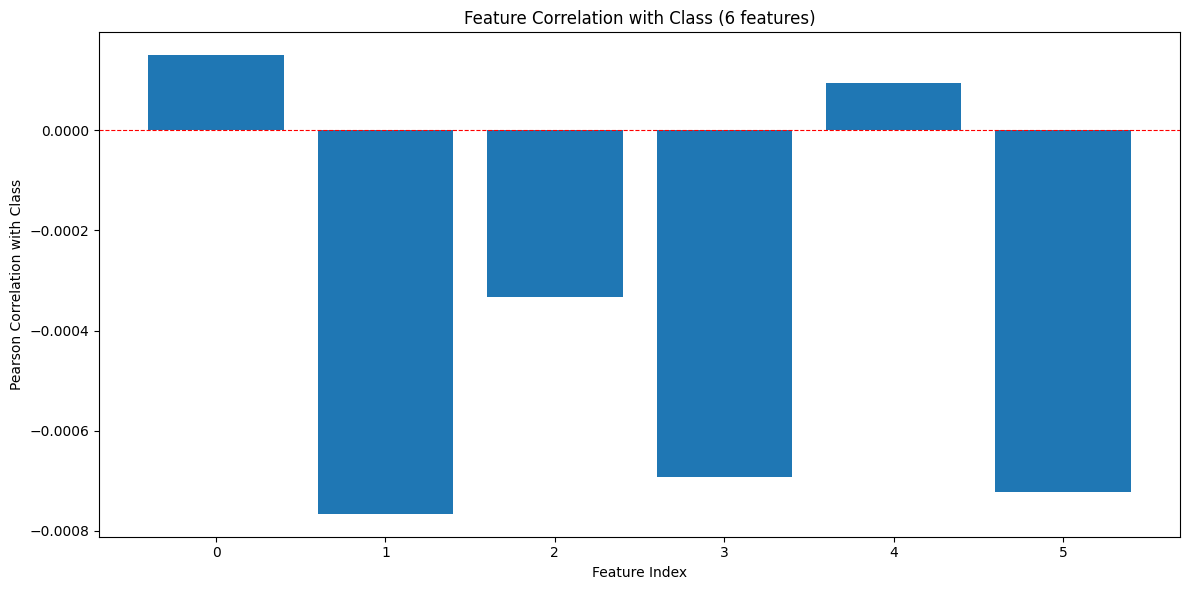

In [17]:

# Calculate correlation between each feature and Class (Pearson correlation coefficient)
correlations = X.corrwith(y['Class'])

# Plot correlation bar chart
plt.figure(figsize=(12, 6))
plt.bar(range(len(correlations)), correlations.values)
plt.xlabel('Feature Index')
plt.ylabel('Pearson Correlation with Class')
plt.title(f'Feature Correlation with Class ({len(correlations)} features)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


## Build Pipeline (Imputer → StandardScaler → Classifier)


In [20]:
from sklearn.neighbors import KNeighborsClassifier

# Pipeline: imputation → standardization → KNN classifier
# (feature selection already done above, MI=0 features removed)
pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Fit on training data
pipeline.fit(X_train, y_train.values.ravel())

# Evaluate on test data
train_score = pipeline.score(X_train, y_train.values.ravel())
test_score = pipeline.score(X_test, y_test.values.ravel())

print(f'Train accuracy: {train_score:.4f}')
print(f'Test accuracy:  {test_score:.4f}')


Train accuracy: 0.6027
Test accuracy:  0.4141


## Diagnose: why accuracy is low?


In [ ]:
# 1. Class distribution
print('=== Class Distribution ===')
print(y.value_counts())
print(f'Baseline (always predict majority): {y.value_counts().max() / len(y):.4f}\n')

# 2. Train vs test gap (overfitting?)
print(f'Train-Test Gap: {train_score - test_score:.4f} (large = overfitting)\n')

# 3. Check if X_train still has NaN
print(f'NaN in X_train: {X_train.isnull().sum().sum()}')
print(f'NaN in X_test:  {X_test.isnull().sum().sum()}\n')

# 4. Try different k values
print('=== Effect of k (n_neighbors) ===')
for k in [1, 3, 5, 7, 10, 15, 20, 30]:
    pipe = Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train.values.ravel())
    t_acc = pipe.score(X_train, y_train.values.ravel())
    v_acc = pipe.score(X_test, y_test.values.ravel())
    print(f'k={k:2d}  Train: {t_acc:.4f}  Test: {v_acc:.4f}')


=== Class Distribution ===
Class
2        599228
3        400780
1        199992
Name: count, dtype: int64
Baseline (always predict majority): 0.4994

Train-Test Gap: 0.1886 (large = overfitting)

NaN in X_train: 0
NaN in X_test:  0

=== Effect of k (n_neighbors) ===
